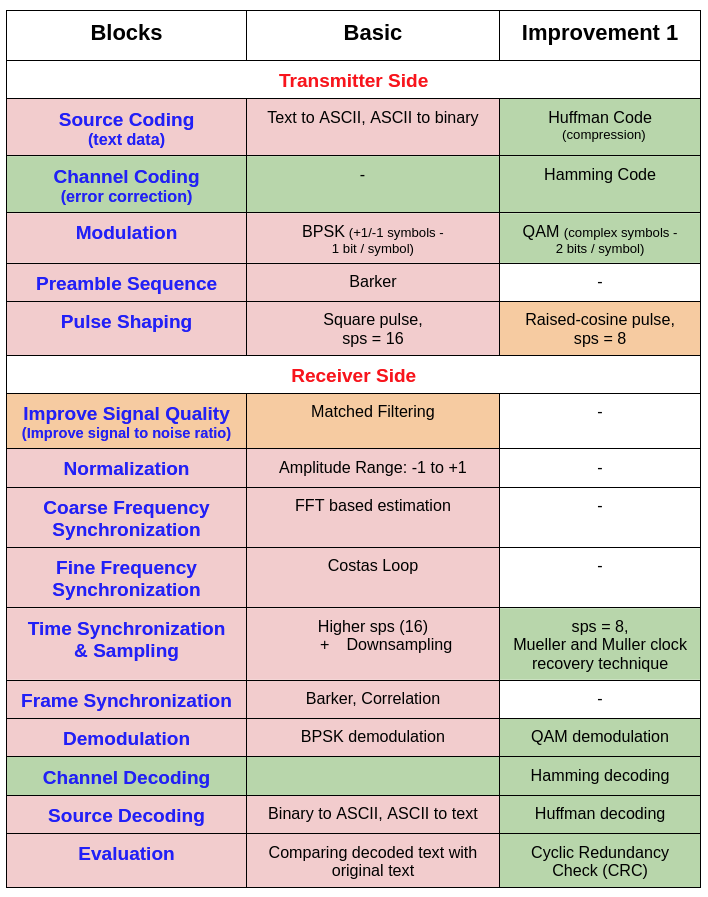

# Cyclic Redundancy Check (CRC)

- Cyclic Redundancy Check (CRC) is an error-detection technique used in digital communication and data storage systems to detect accidental changes (errors) in raw data.

- It is based on binary division using modulo-2 arithmetic (i.e., XOR operations).

- It works by treating the data as a binary polynomial, dividing it by a fixed generator polynomial, and using the remainder as a check value (called the CRC bits).

- When the receiver gets the data, it performs the same division — if the remainder is 0, the received data is assumed error-free; otherwise, error occurred.

- Message bits $M(x)$ are represented as a binary polynomial.

- A generator polynomial
$G(x)$ of degree $r$ (CRC length) is used. if $M(x)=x^{m−1}+⋯+1$ and generator polynomial: $G(x) = 1x^r+ g_{r-1}x^{r-1}+\ldots+g_0$, where $g_x \in \{0, 1\}$.

- The transmitted polynomial is: $T(x) = x^r M(x) + R(x)$, where where $R(x)$ is the remainder obtained after dividing $x^rM(x)$ by $G(x$).


# Example

- Message bits: $M=1010011010$ ----------(10 bits), $M(x) = x^9+x^7+x^4+x^3+x$
- Generator polynomial: $G(x)=x^4+x+1$, generator bits $G=10011$ (degree = $r$ = 4 → CRC = 4 bits)
### Steps

**Append 4 zeros:** Append degree $r = 4$ zeros ----> $M'=$ $x^r M(x) = x^{13}+x^{11}+x^8+x^7+x^5 = 10100110100000$

**Perform binary division :** Perform binary division using modulo-2 arithmetic (i.e., XOR operations)

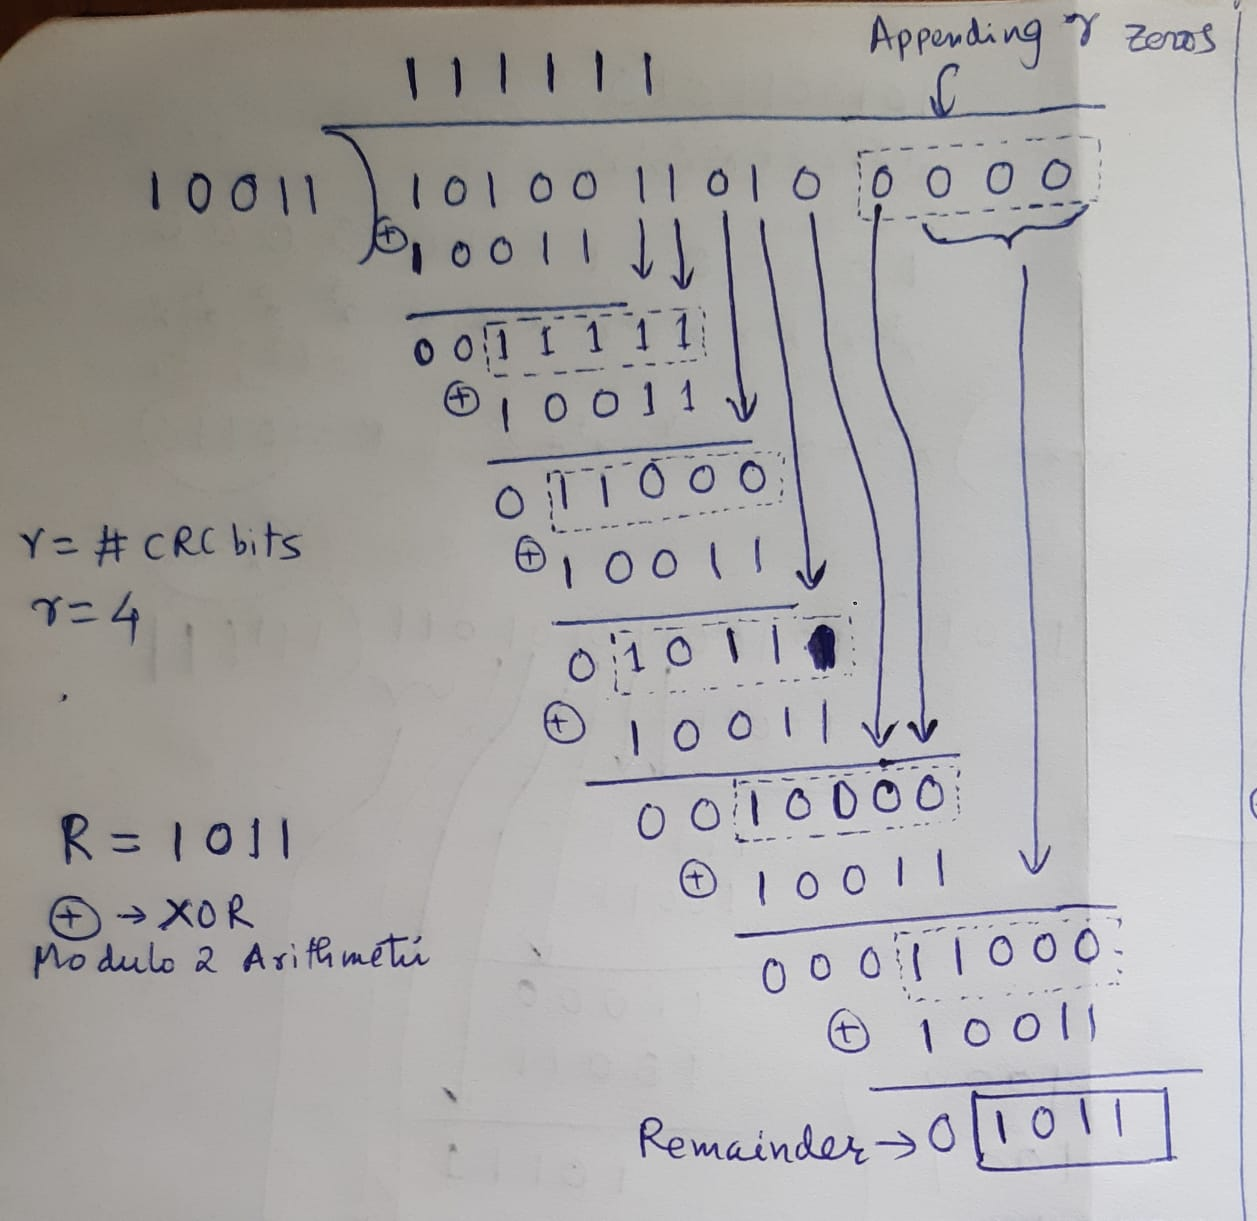

$R = 1011$

        



                


**Append remainder to message:** Append remainder to message $T=10100110101011$. This is the transmitted frame (14 bits).

**Receiver's Check:**   The receiver divides the received bits $T$ by $G$. If remainder = 0 → no error detected, otherwise, error occurred.

## Polynomial division (alternative to binary division):

- $R(x) = x^r M(x) / G(x) =(x^{13}+x^{11}+x^8+x^7+x^5) / (x^4+x+1)$

- $R(x) = x^3 + x + 1$

-  $T(x) = x^r M(x) + R(x) = x^{13}+x^{11}+x^8+x^7+x^5+x^3+x+1$
- $T=10100110101011$

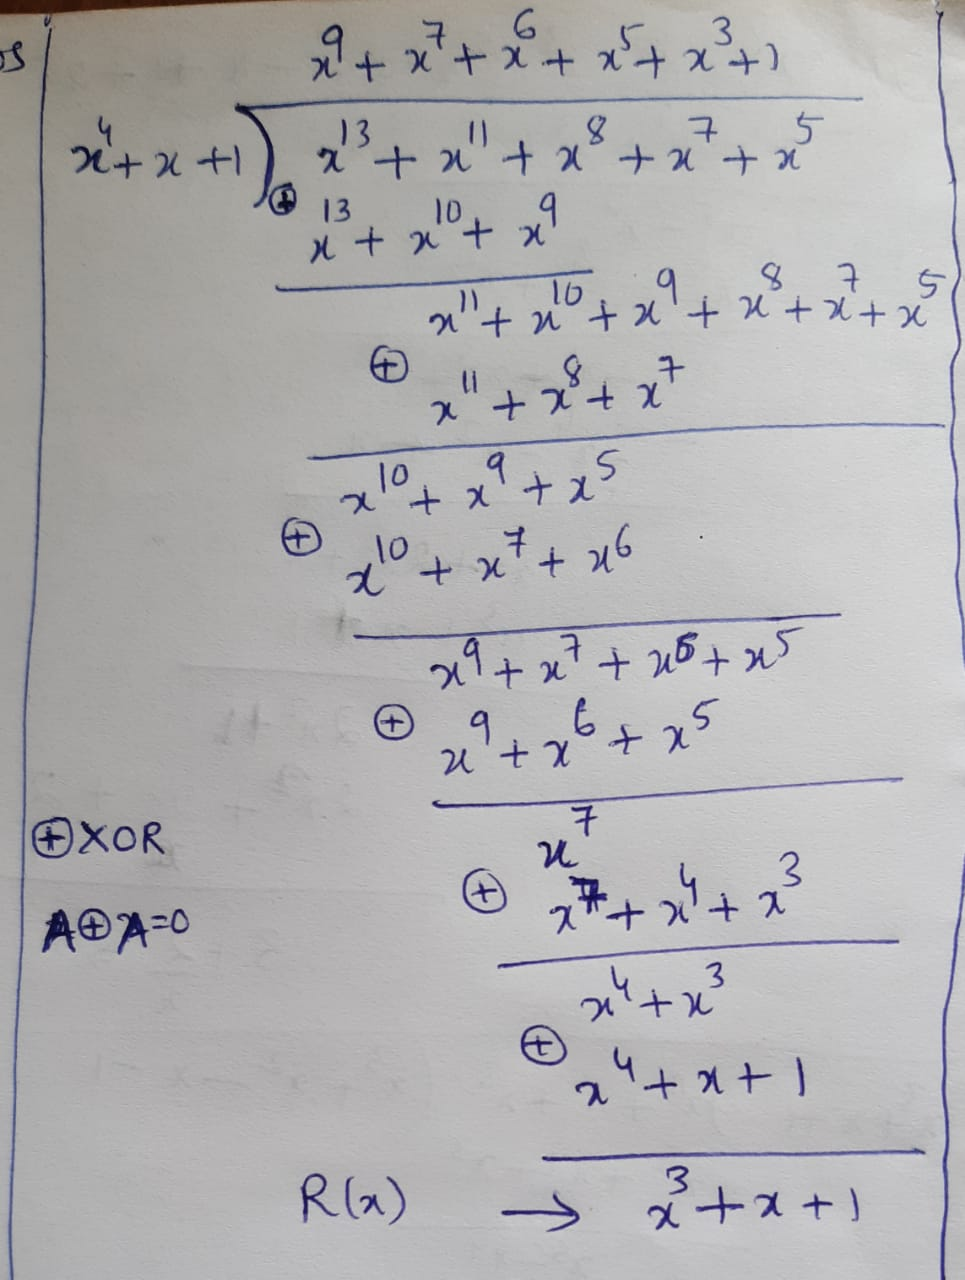



# Error Detection Capability
| Error Type                    | Detection                                        |
| ----------------------------- | ------------------------------------------------ |
| **Single-bit error**          | Always detected if $G(x)$  has ≥2 terms.        |
| **Double-bit error**          | Detected if $G(x)$  doesn’t divide $x^k + 1$. |
| **Odd number of errors**      | Detected if $G(x)$ has factor $(x + 1)$ .     |
| **Burst error of length ≤ r** | Always detected.                                 |
| **Burst error of length > r** | Detected with probability $1 - 2^{-r}$.        |


### Burst Error

- A burst error is a group (or cluster) of bits in which two or more bits are corrupted, and
the first and last bits of the group are wrong,
but bits in between may be right or wrong.

- So, it's not random single-bit errors scattered — it's a continuous segment of bits affected by noise or interference.

- Example: Transmitted: 1 0 0 1 1 0 1 0 1 1, Received:     1 1 1 0 0 1 0 0 1 1

- Here, bits from positions 2 to 7 are affected —
so it's a 6-bit burst error.


# Probability of Undetected Errors

- For random errors, the probability that an error pattern escapes detection is $P_{\rm undetected} = 2^{-r}$, where $r$ = number of CRC bits.

- For example, with a message length $m=5$ and $r=3$ CRC bits, the transmitted message has $m+r= 8$ bits. Among the $2^8=256$ possible received patterns, only $2^m=32$ correspond to valid codewords that produce a zero remainder upon division by the same generator polynomial $G$. Hence, the probability of an undetected error is: $P_{\rm undetected} = 32/256 = 1/8 = 2^{-3}$

- Error detection probability = $1 - 2^{-r}$


# Difference between Hamming and CRC

| Feature               | Hamming Code                                                         | CRC                                                                                                                |
| --------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------ |
| **Error detection**   | Can detect **2-bit errors**           | Can detect **burst errors** and multiple-bit errors with high probability                                          |
| **Error correction**  | Can **correct single-bit errors** (some variants correct double-bit) | Typically **cannot correct errors**; only detects them                                                             |



# Selection of Good Generator Polynomials

- A good $G(x)$: Has at least two terms (ensures single-bit detection)

- Contains factor $(x+1)$ (detects all odd-bit errors)

- Does not divide $x^k+1$ for small k

- Maximizes minimum distance between valid codewords

# Common CRC Standards

| Standard                     | Polynomial (Hex) | Polynomial (Binary)               | Degree |
| ---------------------------- | ---------------- | --------------------------------- | ------ |
| CRC-4-ITU                    | 0x3              | 10011                             | 4      |
| CRC-8                        | 0x07             | 100000111                         | 8      |
| CRC-12                       | 0x80F            | 1000000001111                     | 12     |
| CRC-16-IBM                   | 0x8005           | 1100000000000101                  | 16     |
| CRC-32 (Ethernet, ZIP, etc.) | 0x04C11DB7       | 100000100110000010001110110110111 | 32     |


# Task 1: Compute CRC

- $m = 10100111001011100101$ ------------>(20 bits), $G = 100000111$-----> (8bits)

- Compute CRC for given message bits $m$ and obtain transmitting bits $T$


In [ ]:
# Write your code here.




# Task 2: Detection of Error

- Different 20 bits message sequence is taken : $m'$, computed 8-bit CRC $R'$ of it using the same $G = 100000111$, transmited the resultign $T'$ of 28 bit sequencene

- Received the following bit sequence, $Z = 1101010010111001010100110011$ ----> (28 bits)

- Check whether error occured in the received sequence.



In [ ]:
# Write your code here




# Implement CRC in End-to-End Communication using SDRs

- For the transmitter and receiver codes used in end-to-end communication with SDRs in Lab 6, include the improved techniques along with the basic operations.

- Replace ASCII coding with Huffman coding for efficient source compression.

- Implement (7,4) Hamming coding for error detection and correction.

- After Hamming encoding, append an 8-bit CRC for every 200 bits, resulting in a 208-bit transmission block each time.

- At the receiver, perform Hamming decoding first. For every 200-bit block obtained from Hamming decoding, verify its CRC.

- If a CRC error is detected, skip the other decoding blocks. Otherwise, decode the verified 200-bit sequence using Huffman decoding to reconstruct the original text message.

- Repeat the above steps for every remaining 200 bit message bits chunks.

- After all the chunks were transmitted compare with the entire decoded text message with the original one.

- Automate the above steps (selecting different message bit chunks) using for loops.

- Skip plotting and printing codes in end-to-end communication code provided.

- Optimize the steps to maximize the accuracy in received text message and transmit and receive timings.






## After Implementing all the steps mentioned above transmit and receive following text message.

In [1]:
text_message = '''Mental health is vital to overall well-being, influencing how we think, feel, and act. 
It shapes relationships, decisions, and coping abilities. Yet, stigma often prevents people from seeking help. 
Common conditions like depression, anxiety, and stress are treatable with support. 
Promoting mental health means creating safe spaces, encouraging openness, and providing care access. 
Early recognition of distress—such as sadness, withdrawal, or sleep changes—enables timely help. 
Therapy, medication, and self-care practices like mindfulness and exercise improve resilience. 
Schools, workplaces, and governments must prioritize awareness, reduce stigma, and invest in accessible services. Mental health is essential, not optional.
'''

print(text_message)

print(len(text_message))

Mental health is vital to overall well-being, influencing how we think, feel, and act. 
It shapes relationships, decisions, and coping abilities. Yet, stigma often prevents people from seeking help. 
Common conditions like depression, anxiety, and stress are treatable with support. 
Promoting mental health means creating safe spaces, encouraging openness, and providing care access. 
Early recognition of distress—such as sadness, withdrawal, or sleep changes—enables timely help. 
Therapy, medication, and self-care practices like mindfulness and exercise improve resilience. 
Schools, workplaces, and governments must prioritize awareness, reduce stigma, and invest in accessible services. Mental health is essential, not optional.

736


# Transmitter Code

In [ ]:
# Write your code here










# Receiver Code (Do in separate Notebook)